In [1]:
import os
import sys
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))

from src.optimization.optimizer import MicrogridOptimizer
from src.optimization.microgrid import Microgrid
from src.models.building_load import BuildingLoad

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16
})

In [2]:
# creates a microgrid object with specified components that holds data and parameters
microgrid = Microgrid(
    loads=['StudentServices'], 
    pv_generators=['BioEngineeringPV'], 
    batteries=['BatteryStorage'] 
)

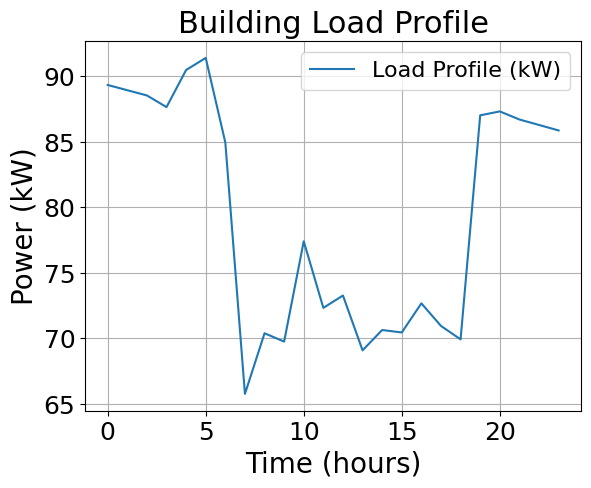

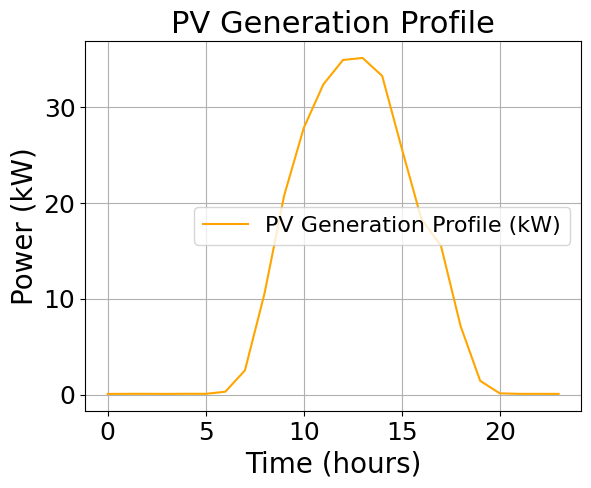

In [3]:



load_profile = microgrid.loads[0].get_load_profile('2016-07-16', '2016-07-17')  # kW
T = len(load_profile)

plt.figure()
plt.plot(range(T), load_profile, label='Load Profile (kW)')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Building Load Profile')
plt.legend()
plt.grid()
plt.show()

pv_profile = microgrid.pv_generators[0].get_generation_profile('2016-07-16', '2016-07-17')  # kW

plt.figure()
plt.plot(range(T), pv_profile, label='PV Generation Profile (kW)', color='orange')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV Generation Profile')
plt.legend()
plt.grid()
plt.show()




In [ ]:
microgrid.optimize(start_date='2016-07-16', end_date='2016-07-17')